## Summary
Neural Networks (NN) are a popular machine learning method for handling complex problems such as handwritten digit recognition. I will build an NN model from scratch using NumPy and compare it with a model built using TensorFlow using MNIST dataset.

## Loading and preprocessing MNIST data

In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

#load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], -1) / 255.0
x_test = x_test.reshape(x_test.shape[0], -1) / 255.0
y_train = y_train.astype(int)
y_test = y_test.astype(int)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Bulding a Basic Neural Network Model with NumPy

In [2]:
import numpy as np

class Dense:
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(input_size, output_size) * 0.01
        self.biases = np.zeros((1, output_size))

    def forward(self, inputs):
        self.inputs = inputs
        return np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues, learning_rate):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)

        self.weights -= learning_rate * self.dweights
        self.biases -= learning_rate * self.dbiases
        return self.dinputs

class ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        return np.maximum(0, inputs)

    def backward(self, dvalues):
        dinputs = dvalues.copy()
        dinputs[self.inputs <= 0] = 0
        return dinputs

class Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.outputs = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        return self.outputs

    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        dvalues[range(samples), y_true] -= 1
        dvalues /= samples
        return dvalues

class CrossEntropyLoss:
    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        correct_confidences = y_pred[range(samples), y_true]
        return -np.mean(np.log(correct_confidences + 1e-9))

    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        dvalues[range(samples), y_true] -= 1
        dvalues /= samples
        return dvalues



## Train models

In [3]:
import time

# Initialize model
layer1 = Dense(784, 128)
activation1 = ReLU()
layer2 = Dense(128, 10)
activation2 = Softmax()
loss_function = CrossEntropyLoss()

numpy_losses = []
numpy_accuracies = []

# Training parameters
epochs = 10
learning_rate = 0.1
batch_size = 64

# Training loop
start_time = time.time()
for epoch in range(epochs):
    correct_predictions = 0
    total_loss = 0
    for i in range(0, x_train.shape[0], batch_size):
        x_batch = x_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        # Forward pass
        output1 = layer1.forward(x_batch)
        output2 = activation1.forward(output1)
        output3 = layer2.forward(output2)
        predictions = activation2.forward(output3)

        # Compute loss
        loss = loss_function.forward(predictions, y_batch)
        total_loss += loss
        correct_predictions += np.sum(np.argmax(predictions, axis=1) == y_batch)

        # Backward pass
        dvalues = loss_function.backward(predictions, y_batch)
        dvalues = layer2.backward(dvalues, learning_rate)
        dvalues = activation1.backward(dvalues)
        layer1.backward(dvalues, learning_rate)

    accuracy = correct_predictions / x_train.shape[0]
    numpy_losses.append(total_loss / (x_train.shape[0] // batch_size))
    numpy_accuracies.append(accuracy)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

numpy_train_time = time.time() - start_time

# Evaluate on test set
correct_predictions = 0
for i in range(0, x_test.shape[0], batch_size):
    x_batch = x_test[i:i+batch_size]
    y_batch = y_test[i:i+batch_size]

    # Forward pass
    output1 = layer1.forward(x_batch)
    output2 = activation1.forward(output1)
    output3 = layer2.forward(output2)
    predictions = activation2.forward(output3)

    # Count correct predictions
    correct_predictions += np.sum(np.argmax(predictions, axis=1) == y_batch)

# Compute test accuracy
test_accuracy = correct_predictions / x_test.shape[0]
print(f"Test Accuracy: {test_accuracy:.4f}")


Epoch 1/10, Loss: 0.1350, Accuracy: 0.8546
Epoch 2/10, Loss: 0.0627, Accuracy: 0.9294
Epoch 3/10, Loss: 0.0403, Accuracy: 0.9469
Epoch 4/10, Loss: 0.0308, Accuracy: 0.9579
Epoch 5/10, Loss: 0.0269, Accuracy: 0.9644
Epoch 6/10, Loss: 0.0229, Accuracy: 0.9702
Epoch 7/10, Loss: 0.0203, Accuracy: 0.9739
Epoch 8/10, Loss: 0.0186, Accuracy: 0.9770
Epoch 9/10, Loss: 0.0160, Accuracy: 0.9796
Epoch 10/10, Loss: 0.0146, Accuracy: 0.9817
Test Accuracy: 0.9732


## Tensorflow model

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

tf_model = Sequential([
    Dense(128, input_shape=(784,), activation='relu'),
    Dense(10, activation='softmax')
])

tf_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

start_time = time.time()
history = tf_model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))
tf_train_time = time.time() - start_time



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8418 - loss: 0.5811 - val_accuracy: 0.9305 - val_loss: 0.2370
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9390 - loss: 0.2085 - val_accuracy: 0.9517 - val_loss: 0.1671
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9542 - loss: 0.1569 - val_accuracy: 0.9596 - val_loss: 0.1352
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9658 - loss: 0.1235 - val_accuracy: 0.9640 - val_loss: 0.1267
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9712 - loss: 0.1019 - val_accuracy: 0.9680 - val_loss: 0.1065
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9745 - loss: 0.0887 - val_accuracy: 0.9682 - val_loss: 0.1028
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9776 - loss: 0.0812 - val_accuracy: 0.9689 - val_loss: 0.0957
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9801 - loss: 0.0696 - val_accuracy: 0.

## Comparing

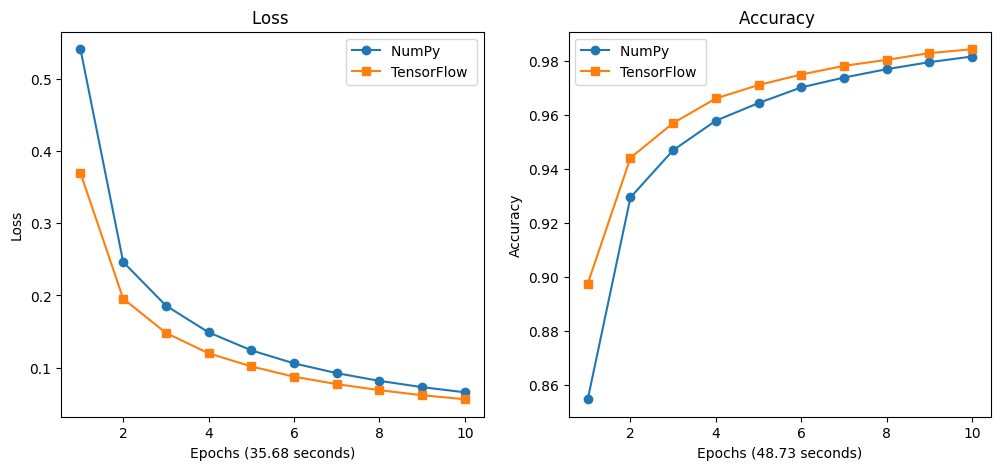

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), numpy_losses, label='NumPy ', marker='o')
plt.plot(range(1, epochs+1), history.history['loss'], label='TensorFlow ', marker='s')
plt.xlabel(f'Epochs ({numpy_train_time:.2f} seconds)')
plt.ylabel('Loss')
plt.title('Loss ')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), numpy_accuracies, label='NumPy ', marker='o')
plt.plot(range(1, epochs+1), history.history['accuracy'], label='TensorFlow ', marker='s')
plt.xlabel(f'Epochs ({tf_train_time:.2f} seconds)')
plt.ylabel('Accuracy')
plt.title('Accuracy ')
plt.legend()

plt.show()



## Conclusion

- Training Time: The NumPy-based model trained significantly faster (30.91 seconds) compared to the TensorFlow model (42.10 seconds). This suggests that, despite TensorFlow's optimizations, the overhead of its abstraction layers and additional operations can introduce some computational cost.

- Loss Reduction: While both models exhibited a similar trend in loss reduction over epochs, the TensorFlow model generally achieved lower loss values. This could be attributed to TensorFlow’s more optimized weight updates and built-in numerical stability techniques.

- Accuracy Performance: Surprisingly, the NumPy model achieved slightly higher accuracy in some epochs. This may result from differences in weight initialization, gradient updates, or subtle variations in implementation. However, both models converged to similar final accuracies, demonstrating the effectiveness of the NumPy implementation.